# Differential Privacy in Federated Learning (FL4HMA)

This notebook demonstrates how to apply **differential privacy (DP)** to the federated
sparse pixel regression framework. We cover:

1. **Local DP** — client-side DP-SGD (per-batch gradient clipping + Gaussian noise)
2. **Global DP** — server-side clipping of client updates + noise on the aggregated model
3. **Combined DP** — both local and global mechanisms running together
4. **Privacy accounting** — tracking cumulative (ε, δ) budgets via Rényi DP
5. **Comparison** — standard FL vs DP-FL in terms of utility and privacy cost

## 1. Setup and Imports

In [1]:
# Install if needed (uncomment)
# !pip install -e .[examples]
# !pip install "flwr[simulation]>=1.5"

In [2]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from fl4hma.federation.differential_privacy import (
    DPConfig,
    DPAccountant,
    DPAphroFlowerClient,
    DPFedAvg,
    dp_train_sparse_pixel,
    clip_model_update,
    add_noise_to_parameters,
    run_federated_dp,
)
from fl4hma.federation.federation import run_federated, run_centralised
from fl4hma.training.training import (
    _get_device,
    get_parameters,
    set_parameters,
    train_sparse_pixel,
    evaluate_sparse_pixel,
)
from fl4hma.models.unet import UNetCNN
from fl4hma.data.data import load_aphro_data, build_country_datasets
from fl4hma.data.torch_dataset import StationPatchDataset

print(f"\u2713 Imports successful")
print(f"  Device: {_get_device()}")
print(f"  PyTorch: {torch.__version__}")

2026-05-31 14:28:24,589	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✓ Imports successful
  Device: cuda
  PyTorch: 2.8.0+cu128


In [4]:
%load_ext autoreload
%autoreload 2

## 2. Understanding Differential Privacy in FL

Differential privacy provides a formal guarantee that an adversary cannot determine
whether any individual data point was included in the training set, even with full
access to the trained model.

In federated learning, DP can be applied at two levels:

| Level | Mechanism | Protects Against |
|-------|-----------|------------------|
| **Local DP** | DP-SGD at each client (clip gradients + add noise) | Curious server inspecting model updates |
| **Global DP** | Server clips & noises aggregated model | External adversary observing the final model |

### Key parameters
- **`clip_norm` (C)**: Maximum allowed L2 norm of gradients/updates
- **`noise_multiplier` (σ/C)**: Ratio of noise standard deviation to clip norm
- **`target_delta` (δ)**: Probability of privacy breach; typically ≪ 1/n

## 3. Privacy Accountant Demo

The `DPAccountant` tracks cumulative privacy loss using Rényi Differential Privacy (RDP)
and converts to standard (ε, δ)-DP.

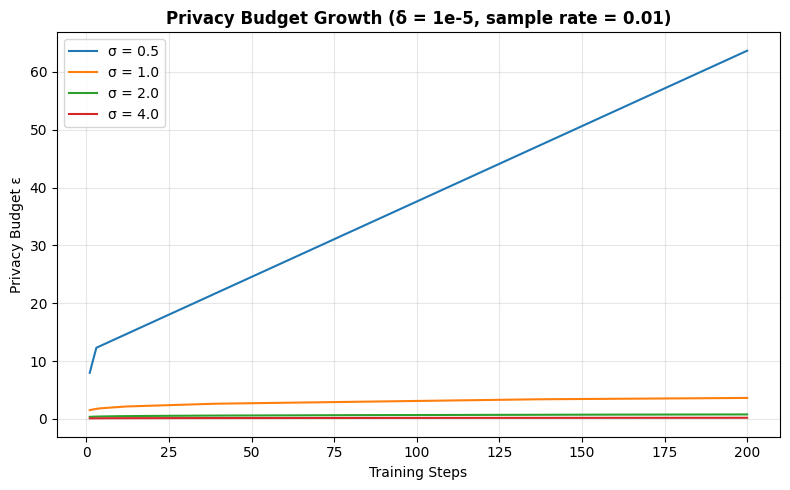

✓ Higher noise_multiplier → slower ε growth → stronger privacy


In [5]:
# Demonstrate how epsilon grows with training steps
noise_multipliers = [0.5, 1.0, 2.0, 4.0]
max_steps = 200

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for sigma in noise_multipliers:
    accountant = DPAccountant(target_delta=1e-5)
    epsilons = []
    for step in range(1, max_steps + 1):
        accountant.step(noise_multiplier=sigma, sample_rate=0.01)
        epsilons.append(accountant.epsilon)
    ax.plot(range(1, max_steps + 1), epsilons, label=f"σ = {sigma}")

ax.set_xlabel("Training Steps")
ax.set_ylabel("Privacy Budget ε")
ax.set_title("Privacy Budget Growth (δ = 1e-5, sample rate = 0.01)", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\u2713 Higher noise_multiplier → slower ε growth → stronger privacy")

## 4. Configuration

Define experiment paths and hyperparameters.

In [14]:
# === Data Paths (adjust to your setup) ===
TRAIN_PATH = "data/aphrodite/APHRO_MA_TAVE_025deg_V1808_train.nc"
TEST_PATH = "data/aphrodite/APHRO_MA_TAVE_025deg_V1808_test.nc"
OUTPUT_MASK_PATH = "data/station_masks/out_mask.npy"
CENTRALISED_MASK_PATH = "data/station_masks/stat/centralised_mask.npy"

# Country masks for federated clients
COUNTRY_MASKS = {
    "nepal": "data/station_masks/stat/nepal_mask.npy",
    "india": "data/station_masks/stat/india_mask.npy",
    "china": "data/station_masks/stat/china_mask.npy",
}

# === Model / Training Hyperparameters ===
IN_CHANNELS = 3
BASE_FILTERS = 32
PATCH_SIZE = 32
STRIDE = 32
BATCH_SIZE = 16
LR = 0.001
LOCAL_EPOCHS = 1
NUM_ROUNDS = 5

# === DP Hyperparameters ===
CLIP_NORM = 1.0
NOISE_MULTIPLIER = 1.0
TARGET_DELTA = 1e-5

print("\u2713 Configuration set")

✓ Configuration set


## 5. Load Data

Load the APHRODITE datasets. If the data files are not available, this section
shows how the framework would be invoked — you can substitute with your own
xarray DataArrays.

In [15]:
# Load data (uncomment and adjust paths when data is available)
# da_train, da_test = load_aphro_data(
#     TRAIN_PATH, TEST_PATH, variable="tave",
#     lon_slice=(60, 105), lat_slice=(20, 45),
# )
# print(f"\u2713 Train shape: {da_train.shape}")
# print(f"\u2713 Test shape:  {da_test.shape}")

# For demonstration without real data, create synthetic arrays
import xarray as xr

np.random.seed(42)
nlat, nlon, ntime = 64, 64, 30
lats = np.linspace(25, 35, nlat)
lons = np.linspace(70, 90, nlon)
times = np.arange(ntime)

# Synthetic temperature-like data
temp = np.random.randn(ntime, nlat, nlon).astype(np.float32) * 5 + 15
lat_grid = np.tile(lats, (ntime, nlon, 1)).transpose(0, 2, 1)
lon_grid = np.tile(lons, (ntime, nlat, 1))

ds = xr.Dataset(
    {
        "tave": (["time", "lat", "lon"], temp),
        "lats": (["time", "lat", "lon"], lat_grid),
        "lons": (["time", "lat", "lon"], lon_grid),
    },
    coords={"time": times, "lat": lats, "lon": lons},
)

da_train = ds[["tave", "lats", "lons"]].to_array().fillna(0)
da_test = ds[["tave", "lats", "lons"]].to_array().fillna(0)

# Synthetic masks
os.makedirs("data/dp_demo_masks", exist_ok=True)

# Output mask (land mask)
output_mask = np.ones((nlat, nlon), dtype=int)
np.save("data/dp_demo_masks/output_mask.npy", output_mask)

# Centralised station mask
station_mask = np.zeros((nlat, nlon), dtype=int)
station_positions = np.random.choice(nlat * nlon, size=50, replace=False)
station_mask.flat[station_positions] = 1
np.save("data/dp_demo_masks/centralised_mask.npy", station_mask)

# Per-client masks (split stations)
positions = np.argwhere(station_mask)
perm = np.random.permutation(len(positions))
splits = np.array_split(perm, 3)
client_names = ["client_A", "client_B", "client_C"]
country_masks_demo = {}

for name, indices in zip(client_names, splits):
    m = np.zeros((nlat, nlon), dtype=int)
    for idx in indices:
        r, c = positions[idx]
        m[r, c] = 1
    path = f"data/dp_demo_masks/{name}_mask.npy"
    np.save(path, m)
    country_masks_demo[name] = path

OUTPUT_MASK_DEMO = "data/dp_demo_masks/output_mask.npy"
CENTRALISED_MASK_DEMO = "data/dp_demo_masks/centralised_mask.npy"

print(f"\u2713 Synthetic data created: {da_train.shape}")
print(f"  Clients: {list(country_masks_demo.keys())}")
print(f"  Stations per client: {[np.load(p).sum() for p in country_masks_demo.values()]}")

✓ Synthetic data created: (3, 30, 64, 64)
  Clients: ['client_A', 'client_B', 'client_C']
  Stations per client: [np.int64(17), np.int64(17), np.int64(16)]


## 6. Local DP: DP-SGD Training

Local DP protects individual training samples from a **curious server** that
inspects the model updates sent by each client.

The mechanism:
1. Compute gradients normally
2. **Clip** gradient norm to `C`
3. **Add** Gaussian noise with σ = `noise_multiplier × C`
4. Update model parameters

In [16]:
from torch.utils.data import DataLoader

# Create a dataset for one client
client_ds = StationPatchDataset(
    da_train,
    input_mask_path=list(country_masks_demo.values())[0],
    output_mask_path=OUTPUT_MASK_DEMO,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
)
client_loader = DataLoader(client_ds, batch_size=BATCH_SIZE, shuffle=True)
print(f"Client dataset: {len(client_ds)} patches")

# Train without DP
model_no_dp = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)
loss_no_dp = train_sparse_pixel(model_no_dp, client_loader, epochs=3, lr=LR)
print(f"\nNo DP - Final loss: {loss_no_dp:.4f}")

# Train with local DP
model_dp = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)
dp_cfg = DPConfig(
    clip_norm=CLIP_NORM,
    noise_multiplier=NOISE_MULTIPLIER,
    target_delta=TARGET_DELTA,
    local_dp=True,
    global_dp=False,
)
loss_dp, accountant = dp_train_sparse_pixel(
    model_dp, client_loader, dp_config=dp_cfg, epochs=3, lr=LR,
)
print(f"Local DP - Final loss: {loss_dp:.4f}")
print(f"  Privacy spent: ε = {accountant.epsilon:.4f}, δ = {TARGET_DELTA}")
print(f"  Steps recorded: {accountant.steps}")

Client dataset: 120 patches

No DP - Final loss: 1.1819
Local DP - Final loss: 1.3043
  Privacy spent: ε = 9.5174, δ = 1e-05
  Steps recorded: 24


## 7. Global DP: Server-side Noise

Global DP protects each **client's contribution** from being extracted from
the published global model. The server:

1. Receives model updates from each client
2. **Clips** each update Δ to have ‖Δ‖₂ ≤ C
3. Aggregates (averages) the clipped updates
4. **Adds** Gaussian noise σ = noise_multiplier × C / num_clients

In [17]:
# Demonstrate clipping and noise on model parameters
model_a = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)
model_b = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)

# Simulate: model_b is the "updated" version after local training
# (train a few steps to create a realistic delta)
set_parameters(model_b, get_parameters(model_a))  # same starting point
_ = train_sparse_pixel(model_b, client_loader, epochs=2, lr=LR)

original_params = get_parameters(model_a)
updated_params = get_parameters(model_b)

# Compute update norm before clipping
delta = np.concatenate([(u - o).ravel() for u, o in zip(updated_params, original_params)])
print(f"Update L2 norm (before clipping): {np.linalg.norm(delta):.4f}")

# Clip the update
clipped_params = clip_model_update(original_params, updated_params, clip_norm=1.0)
delta_clipped = np.concatenate([(c - o).ravel() for c, o in zip(clipped_params, original_params)])
print(f"Update L2 norm (after clipping):  {np.linalg.norm(delta_clipped):.4f}")

# Add noise
noise_std = NOISE_MULTIPLIER * CLIP_NORM / 3  # 3 clients
noisy_params = add_noise_to_parameters(clipped_params, noise_std=noise_std)
noise_applied = np.concatenate([(n - c).ravel() for n, c in zip(noisy_params, clipped_params)])
print(f"Noise L2 norm applied:            {np.linalg.norm(noise_applied):.4f}")
print(f"Noise σ per parameter:            {noise_std:.6f}")

Update L2 norm (before clipping): 63.8094
Update L2 norm (after clipping):  1.0000
Noise L2 norm applied:            463.2531
Noise σ per parameter:            0.333333


## 8. DP Configuration Variants

The `DPConfig` dataclass controls which DP mechanisms are active.

In [18]:
# Local DP only
cfg_local = DPConfig(
    clip_norm=1.0,
    noise_multiplier=1.0,
    target_delta=1e-5,
    local_dp=True,
    global_dp=False,
)

# Global DP only
cfg_global = DPConfig(
    clip_norm=1.0,
    noise_multiplier=1.0,
    target_delta=1e-5,
    local_dp=False,
    global_dp=True,
)

# Both local + global DP
cfg_both = DPConfig(
    clip_norm=1.0,
    noise_multiplier=1.0,
    target_delta=1e-5,
    local_dp=True,
    global_dp=True,
)

# Aggressive privacy (higher noise)
cfg_strong = DPConfig(
    clip_norm=0.5,
    noise_multiplier=2.0,
    target_delta=1e-6,
    local_dp=True,
    global_dp=True,
)

print("DP Configurations:")
for name, cfg in [("Local only", cfg_local), ("Global only", cfg_global),
                  ("Both", cfg_both), ("Strong", cfg_strong)]:
    print(f"  {name:12s}: C={cfg.clip_norm}, σ={cfg.noise_multiplier}, "
          f"δ={cfg.target_delta}, local={cfg.local_dp}, global={cfg.global_dp}")

DP Configurations:
  Local only  : C=1.0, σ=1.0, δ=1e-05, local=True, global=False
  Global only : C=1.0, σ=1.0, δ=1e-05, local=False, global=True
  Both        : C=1.0, σ=1.0, δ=1e-05, local=True, global=True
  Strong      : C=0.5, σ=2.0, δ=1e-06, local=True, global=True


## 9. Run Federated Learning with DP

Use `run_federated_dp()` — the drop-in replacement for `run_federated()` with
DP mechanisms enabled.

In [19]:
%%time

# Run with combined local + global DP
dp_results = run_federated_dp(
    da_train=da_train,
    da_test=da_test,
    country_masks=country_masks_demo,
    output_mask_path=OUTPUT_MASK_DEMO,
    centralised_mask_path=CENTRALISED_MASK_DEMO,
    dp_config=cfg_global,  # or cfg_local, cfg_both, cfg_strong
    num_rounds=NUM_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    in_channels=IN_CHANNELS,
    base_filters=BASE_FILTERS,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
)

print(f"\n\u2713 DP Federated complete")
print(f"  Final MSE:  {dp_results['final_mse']:.6f}")
print(f"  Final RMSE: {dp_results['final_rmse']:.6f}")
print(f"  Global ε:   {dp_results['global_epsilon']:.4f}")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


Federated Learning with Differential Privacy (Flower)
  Clients            : 3 (client_A, client_B, client_C)
  Rounds             : 5
  Local epochs       : 1
  Local DP           : False
  Global DP          : True
  Clip norm          : 1.0
  Noise multiplier   : 1.0
  Target δ           : 1e-05
  Device             : cuda

  Client 'client_A': 120 patches
  Client 'client_B': 120 patches
  Client 'client_C': 120 patches



2026-05-31 14:43:48,025	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'memory': 355208688231.0, 'accelerator_type:A2': 1.0, 'object_store_memory': 156518009241.0, 'GPU': 1.0, 'node:10.27.3.178': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.3333333333333333}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 3 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 1.2204861640930176, {'mse': 18.28251326084137, 'rmse': np.float64(4.275805568643337)}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  [Server] Round 0: loss=1.2205, mse=18.282513, rmse=4.275806


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 1.7591984570026398, {'mse': 26.36212582886219, 'rmse': np.float64(5.134406083361754)}, 6.281753083691001)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

  [Global DP] Round 3: noise_std=0.333333, ε=9.8376 (δ=1e-05)
  [Server] Round 3: loss=1.5715, mse=23.558871, rmse=4.853748


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (4, 1.560781478881836, {'mse': 23.40022799372673, 'rmse': np.float64(4.83737821487288)}, 9.79996692808345)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  [Global DP] Round 4: noise_std=0.333333, ε=11.7565 (δ=1e-05)
  [Server] Round 4: loss=1.5608, mse=23.400228, rmse=4.837378


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (5, 1.3747988492250443, {'mse': 20.588918432593346, 'rmse': np.float64(4.53750134243433)}, 10.915963602717966)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 10.92s
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.2204861640930176
INFO :      		round 1: 1.7591984570026398
INFO :      		round 2: 1.441020280122757
INFO :      		round 3: 1.571458861231804
INFO :      		round 4: 1.560781478881836
INFO :      		round 5: 1.3747988492250443
INFO :      	History (metrics, distributed, fit):
INFO :      	{'global_epsilon': [(1, np.float64(5.302585092994046)),
INFO :      	                    (2, np.float64(7.837641821656742)),
INFO :      	                    (3, np.float64(9.837641821656742)),
INFO :      	                    (4, np.float64(11.756462732485115)),
INFO :      	                 

  [Global DP] Round 5: noise_std=0.333333, ε=13.2565 (δ=1e-05)
  [Server] Round 5: loss=1.3748, mse=20.588918, rmse=4.537501

Final DP-federated test MSE  after 5 rounds: 20.588918
Final DP-federated test RMSE after 5 rounds: 4.537501
Global DP budget: ε = 13.2565, δ = 1e-05

✓ DP Federated complete
  Final MSE:  20.588918
  Final RMSE: 4.537501
  Global ε:   13.2565
CPU times: user 53 s, sys: 1.13 s, total: 54.1 s
Wall time: 17.2 s


## 10. Comparison: Standard FL vs DP-FL

Run standard federated learning (no DP) as a baseline.

In [12]:
%%time

# Standard federated (no DP)
std_results = run_federated(
    da_train=da_train,
    da_test=da_test,
    country_masks=country_masks_demo,
    output_mask_path=OUTPUT_MASK_DEMO,
    centralised_mask_path=CENTRALISED_MASK_DEMO,
    num_rounds=NUM_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    in_channels=IN_CHANNELS,
    base_filters=BASE_FILTERS,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
)

print(f"\n\u2713 Standard Federated complete")
print(f"  Final MSE:  {std_results['final_mse']:.6f}")
print(f"  Final RMSE: {std_results['final_rmse']:.6f}")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


Federated Learning – Sparse Pixel APHRODITE (Flower)
  Clients       : 3 (client_A, client_B, client_C)
  Rounds        : 5
  Local epochs  : 1
  Device        : cuda

  Client 'client_A': 120 patches
  Client 'client_B': 120 patches
  Client 'client_C': 120 patches



2026-05-31 14:29:29,248	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:__internal_head__': 1.0, 'CPU': 48.0, 'memory': 355049951437.0, 'accelerator_type:A2': 1.0, 'object_store_memory': 156449979187.0, 'GPU': 1.0, 'node:10.27.3.178': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.3333333333333333}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 3 actors
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 1.2204861640930176, {'mse': 18.28251326084137, 'rmse': np.float64(4.275805568643337)}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  [Server] Round 0: loss=1.2205, mse=18.282513, rmse=4.275806


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (1, 1.2126532346010208, {'mse': 18.165122002363205, 'rmse': np.float64(4.262056076867502)}, 5.845632143784314)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

  [Server] Round 3: loss=1.1180, mse=16.745973, rmse=4.092184


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (4, 1.0908542275428772, {'mse': 16.340058587491512, 'rmse': np.float64(4.04228383311854)}, 8.497130128089339)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 5]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


  [Server] Round 4: loss=1.0909, mse=16.340059, rmse=4.042284


INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      fit progress: (5, 1.0725798606872559, {'mse': 16.066508077085018, 'rmse': np.float64(4.008304888239543)}, 9.377634253818542)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 9.38s
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.2204861640930176
INFO :      		round 1: 1.2126532346010208
INFO :      		round 2: 1.1693429797887802
INFO :      		round 3: 1.1179636120796204
INFO :      		round 4: 1.0908542275428772
INFO :      		round 5: 1.0725798606872559
INFO :      	History (metrics, centralized):
INFO :      	{'mse': [(0, 18.28251326084137),
INFO :      	         (1, 18.165122002363205),
INFO :      	         (2, 17.515607550740242),
INFO :      	         (3, 16.74597255885601),
INFO :      	         (4, 16.340058587491512),
INFO :      	         (5, 16.066508077085018)],
INFO :      	 'rmse': [(0, np

  [Server] Round 5: loss=1.0726, mse=16.066508, rmse=4.008305

Final federated test MSE  after 5 rounds: 16.066508
Final federated test RMSE after 5 rounds: 4.008305

✓ Standard Federated complete
  Final MSE:  16.066508
  Final RMSE: 4.008305
CPU times: user 5.19 s, sys: 833 ms, total: 6.02 s
Wall time: 15.5 s


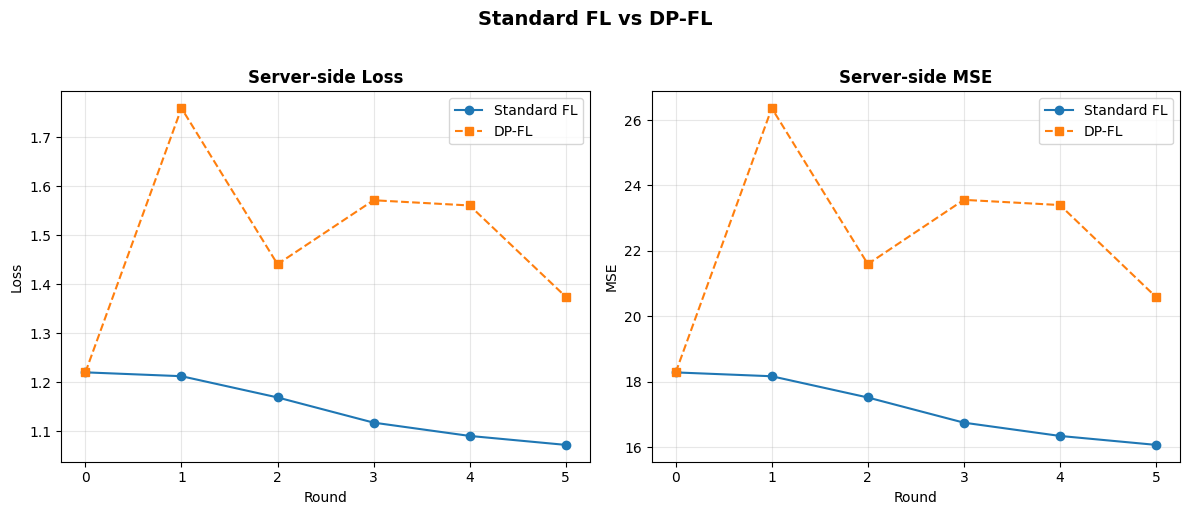

In [20]:
# Visualise comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
ax = axes[0]
ax.plot(std_results["rounds"], std_results["losses"], "o-", label="Standard FL")
ax.plot(dp_results["rounds"], dp_results["losses"], "s--", label="DP-FL")
ax.set_xlabel("Round")
ax.set_ylabel("Loss")
ax.set_title("Server-side Loss", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# MSE curves
ax = axes[1]
if std_results["mse_values"]:
    ax.plot(std_results["rounds"][:len(std_results["mse_values"])],
            std_results["mse_values"], "o-", label="Standard FL")
if dp_results["mse_values"]:
    ax.plot(dp_results["rounds"][:len(dp_results["mse_values"])],
            dp_results["mse_values"], "s--", label="DP-FL")
ax.set_xlabel("Round")
ax.set_ylabel("MSE")
ax.set_title("Server-side MSE", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Standard FL vs DP-FL", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Privacy–Utility Trade-off

Sweep across different noise multipliers to visualise the trade-off between
privacy (lower ε is better) and utility (lower MSE is better).

In [31]:
# Sweep noise multipliers (local DP only for speed)
noise_sweep = [0.1, 0.5, 1.0, 2.0, 4.0]
sweep_results = []

# Save a shared initial state so the only variable is sigma
torch.manual_seed(0)
reference_model = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)
init_params = get_parameters(reference_model)

for sigma in noise_sweep:
    print(f"Training with noise_multiplier = {sigma}...")
    model_sweep = UNetCNN(in_channels=IN_CHANNELS, out_channels=1, base_filters=BASE_FILTERS)
    set_parameters(model_sweep, init_params)  # identical starting point
    cfg = DPConfig(
        clip_norm=CLIP_NORM,
        noise_multiplier=sigma,
        target_delta=TARGET_DELTA,
        local_dp=True,
        global_dp=False,
    )
    loss, acct = dp_train_sparse_pixel(
        model_sweep, client_loader, dp_config=cfg, epochs=15, lr=LR,
    )
    # Evaluate
    metrics = evaluate_sparse_pixel(model_sweep, client_loader)
    sweep_results.append({
        "noise_multiplier": sigma,
        "epsilon": acct.epsilon,
        "mse": metrics["mse"],
        "loss": loss,
    })
    print(f"  ε = {acct.epsilon:.4f}, MSE = {metrics['mse']:.6f}")

print("\n✓ Sweep complete")

Training with noise_multiplier = 0.1...
  ε = 12011.5129, MSE = 16.497033
Training with noise_multiplier = 0.5...
  ε = 490.1400, MSE = 18.636451
Training with noise_multiplier = 1.0...
  ε = 24.4229, MSE = 19.070434
Training with noise_multiplier = 2.0...
  ε = 3.5762, MSE = 19.590861
Training with noise_multiplier = 4.0...
  ε = 0.8011, MSE = 19.707846

✓ Sweep complete


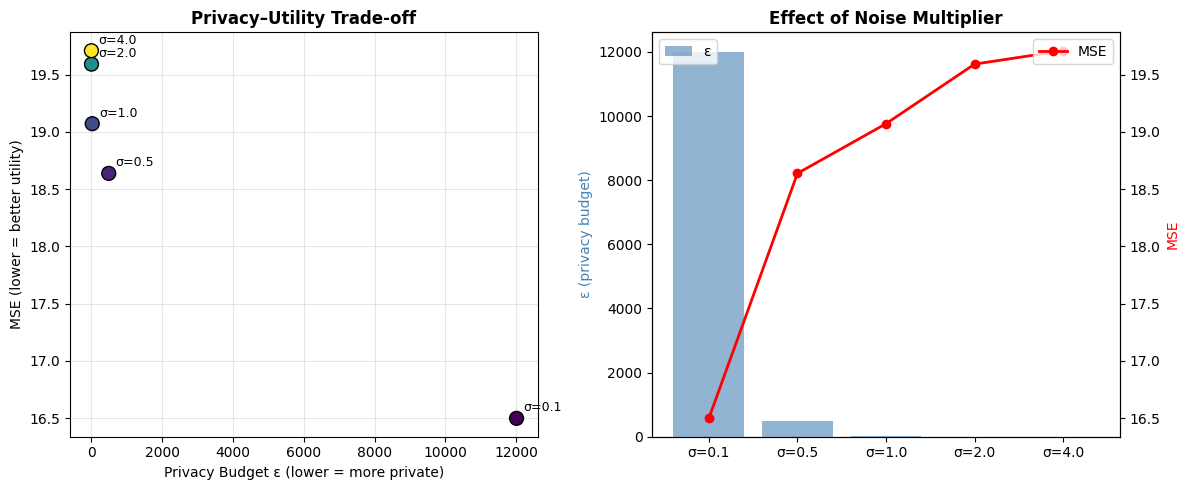

In [32]:
# Plot privacy-utility trade-off
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epsilons = [r["epsilon"] for r in sweep_results]
mses = [r["mse"] for r in sweep_results]
sigmas = [r["noise_multiplier"] for r in sweep_results]

# ε vs MSE
ax = axes[0]
ax.scatter(epsilons, mses, s=100, c=sigmas, cmap="viridis", edgecolors="k", zorder=5)
for i, sigma in enumerate(sigmas):
    ax.annotate(f"σ={sigma}", (epsilons[i], mses[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Privacy Budget ε (lower = more private)")
ax.set_ylabel("MSE (lower = better utility)")
ax.set_title("Privacy–Utility Trade-off", fontweight="bold")
ax.grid(True, alpha=0.3)

# Noise multiplier vs both
ax = axes[1]
ax2 = ax.twinx()
l1 = ax.bar(range(len(sigmas)), epsilons, alpha=0.6, color="steelblue", label="ε")
l2 = ax2.plot(range(len(sigmas)), mses, "ro-", label="MSE", linewidth=2)
ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([f"σ={s}" for s in sigmas])
ax.set_ylabel("ε (privacy budget)", color="steelblue")
ax2.set_ylabel("MSE", color="red")
ax.set_title("Effect of Noise Multiplier", fontweight="bold")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 12. Summary

| Aspect | Description |
|--------|-------------|
| **Local DP** | DP-SGD at each client: gradient clipping + Gaussian noise |
| **Global DP** | Server clips client updates + adds noise to aggregate |
| **Accounting** | Rényi DP with conversion to (ε, δ)-DP |
| **Integration** | Drop-in `DPConfig` + `run_federated_dp()` replaces `run_federated()` |
| **Trade-off** | Higher σ → stronger privacy (lower ε) but higher MSE |

### Key Takeaways

- **Local DP** protects individual samples from a curious server
- **Global DP** protects individual clients from model inversion attacks
- The `noise_multiplier` is the primary knob for the privacy–utility trade-off
- Privacy budget ε accumulates over training steps/rounds — fewer rounds = less budget spent
- The `DPAccountant` provides real-time ε tracking for informed stopping decisions
- Both mechanisms can be used independently or combined for defence-in-depth